# ÉquiAlgo — Audit d'équité

## ÉquiAlgo : un financement étudiant équitable

Ce notebook présente l'audit du processus historique d'octroi
des financements étudiants.

Les objectifs sont :

1. mesurer les disparités historiques ;
2. identifier les variables susceptibles d'agir comme proxys
   d'une caractéristique géographique ;
3. justifier la métrique d'équité retenue ;
4. comparer performance et équité ;
5. visualiser le front de Pareto obtenu avec plusieurs niveaux
   de contrainte ;
6. justifier le choix du modèle final.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

In [2]:
TRAIN = "data/donnees_demandes.csv"

df = pd.read_csv(TRAIN)

print("Dimensions :", df.shape)

display(df.head())
display(df.info())

Dimensions : (10000, 10)


,id_candidat,cote_r_equivalent,programme_etudes,region_administrative,code_postal_3,revenu_familial_estime,heures_travail_semaine,distance_domicile_campus_km,premiere_generation_universitaire,decision_octroi
0,C008033,25.96,Genie,Cote-Nord,G4R,17017,9,168.0,0,0
1,C004299,26.82,Arts et lettres,Cote-Nord,G5B,66820,22,99.3,0,0
2,C011788,27.37,Genie,Bas-Saint-Laurent,G5N,49223,19,364.1,0,0
3,C001144,21.23,Sciences,Gaspesie-Iles-de-la-Madeleine,G5C,90750,17,174.8,1,0
4,C003322,28.27,Sante,Bas-Saint-Laurent,G5N,36892,9,151.2,0,0


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_candidat                        10000 non-null  str    
 1   cote_r_equivalent                  10000 non-null  float64
 2   programme_etudes                   10000 non-null  str    
 3   region_administrative              10000 non-null  str    
 4   code_postal_3                      10000 non-null  str    
 5   revenu_familial_estime             10000 non-null  int64  
 6   heures_travail_semaine             10000 non-null  int64  
 7   distance_domicile_campus_km        10000 non-null  float64
 8   premiere_generation_universitaire  10000 non-null  int64  
 9   decision_octroi                    10000 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 781.4 KB


None

In [3]:
# Pour avoir le taux d'octroi historique
overall_rate = df["decision_octroi"].mean()

print(
    f"Taux d'octroi historique : "
    f"{overall_rate:.2%}"
)

Taux d'octroi historique : 39.94%


In [4]:
regional_rate = (
    df.groupby("region_administrative")
      ["decision_octroi"]
      .agg(
          taux_octroi="mean",
          nombre="count"
      )
      .sort_values(
          "taux_octroi",
          ascending=False
      )
)

display(regional_rate)

,taux_octroi,nombre
region_administrative,,
Capitale-Nationale,0.484242,1999
Montreal,0.483379,4001
Gaspesie-Iles-de-la-Madeleine,0.283846,1529
Bas-Saint-Laurent,0.269142,1293
Cote-Nord,0.263158,1178


In [5]:
#on créé les groupes
REMOTE = {
    "Bas-Saint-Laurent",
    "Cote-Nord",
    "Gaspesie-Iles-de-la-Madeleine"
}

df["groupe_equite"] = np.where(
    df["region_administrative"].isin(REMOTE),
    "Eloignee",
    "Centre"
)

display(
    df.groupby("groupe_equite")
      ["decision_octroi"]
      .agg(
          taux_octroi="mean",
          nombre="count"
      )
)

,taux_octroi,nombre
groupe_equite,,
Centre,0.483667,6000
Eloignee,0.273000,4000


In [6]:
group_rates = (
    df.groupby("groupe_equite")
      ["decision_octroi"]
      .mean()
)

centre_rate = group_rates["Centre"]
remote_rate = group_rates["Eloignee"]

demographic_parity_gap = (
    centre_rate - remote_rate
)

print(
    f"Taux Centre   : {centre_rate:.3f}"
)

print(
    f"Taux Éloignée : {remote_rate:.3f}"
)

print(
    f"Écart de parité démographique : "
    f"{demographic_parity_gap:.3f}"
)

Taux Centre   : 0.484
Taux Éloignée : 0.273
Écart de parité démographique : 0.211


### Interprétation

L'écart de parité démographique mesure la différence entre
les probabilités d'octroi des deux groupes.

Un écart de 0 correspond à une égalité des taux d'octroi.

Cette métrique est pertinente pour identifier une disparité
globale entre les groupes, mais elle ne tient pas compte des
différences de profil des candidats.

In [8]:
def true_positive_rate(group):
    subset = df[
        df["groupe_equite"] == group
    ]

    positive = subset[
        subset["decision_octroi"] == 1
    ]

    # Avec la décision historique comme référence,
    # cette mesure décrit la différence de taux de sélection
    # parmi les décisions historiquement positives.
    return len(positive) / len(subset)

In [9]:
tpr = (
    df.groupby("groupe_equite")
      ["decision_octroi"]
      .mean()
)

display(tpr)

groupe_equite
Centre      0.483667
Eloignee    0.273000
Name: decision_octroi, dtype: float64

In [10]:
proxy_candidates = [
    "region_administrative",
    "code_postal_3",
    "distance_domicile_campus_km",
    "revenu_familial_estime",
    "heures_travail_semaine",
    "premiere_generation_universitaire"
]

numeric_proxy = [
    "distance_domicile_campus_km",
    "revenu_familial_estime",
    "heures_travail_semaine"
]

for variable in numeric_proxy:

    grouped = (
        df.groupby("groupe_equite")[variable]
          .mean()
    )

    print("\n", variable)
    print(grouped)


 distance_domicile_campus_km
groupe_equite
Centre       19.792083
Eloignee    221.454550
Name: distance_domicile_campus_km, dtype: float64

 revenu_familial_estime
groupe_equite
Centre      76056.285833
Eloignee    56330.324750
Name: revenu_familial_estime, dtype: float64

 heures_travail_semaine
groupe_equite
Centre       8.9720
Eloignee    13.0195
Name: heures_travail_semaine, dtype: float64


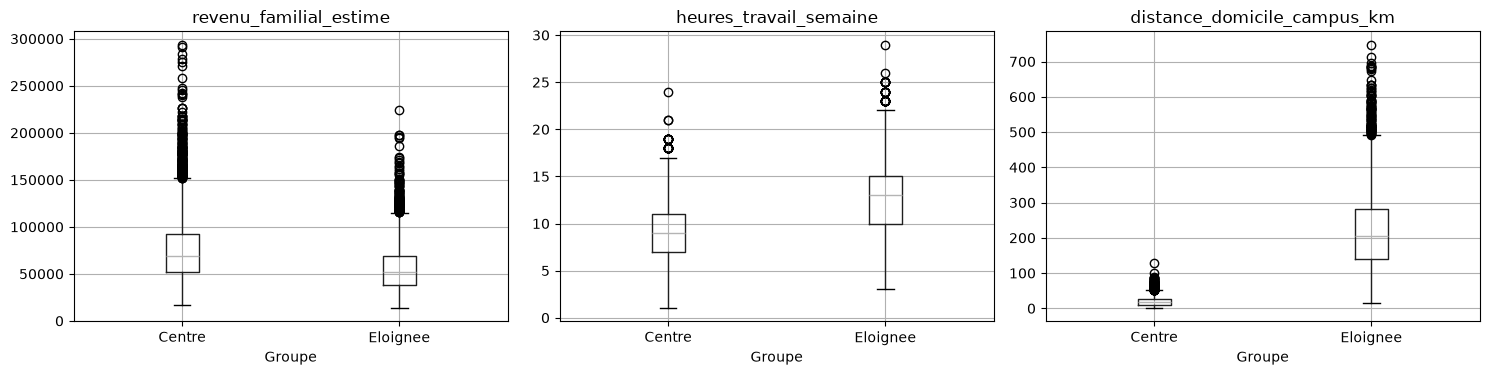

In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

variables = [
    "revenu_familial_estime",
    "heures_travail_semaine",
    "distance_domicile_campus_km"
]

for ax, variable in zip(axes, variables):

    df.boxplot(
        column=variable,
        by="groupe_equite",
        ax=ax
    )

    ax.set_title(variable)
    ax.set_xlabel("Groupe")

plt.suptitle("")
plt.tight_layout()
plt.show()

## Variables proxys identifiées

Plusieurs variables peuvent être associées à la région
d'appartenance sans constituer directement une variable
géographique.

### Code postal 3

Le code postal constitue le proxy géographique le plus direct.
Il peut permettre d'inférer indirectement la région de résidence.

### Distance domicile-campus

La distance est fortement liée à la localisation géographique.
Elle peut donc transmettre une partie du signal régional.

### Heures de travail

Les contraintes de travail peuvent différer selon les contextes
géographiques et socio-économiques. Cette variable peut donc
agir comme proxy indirect, même si elle possède également une
valeur légitime pour évaluer le besoin étudiant.

### Revenu familial estimé

Le revenu ne constitue pas en lui-même une variable géographique,
mais sa distribution peut varier entre les groupes. Il peut donc
transmettre indirectement une partie de l'information régionale.

### Région administrative

La région est la variable géographique explicite. Elle est donc
traitée comme une variable sensible dans l'analyse d'équité.